<a href="https://colab.research.google.com/github/soongnie/aieyes1/blob/main/3%EC%A3%BC%EC%B0%A8_%ED%83%80%EC%9D%B4%ED%83%80%EB%8B%891_%EC%A0%84%EB%B0%98%EB%B6%801.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%matplotlib inline

# %: 주피터 계열 환경에서 쓰는 매직 명령어
# 그래프를 별도의 창이 아니라 노트북 셀 안에 바로 출력하라는 뜻

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [ ]:
'''
타이타닉 데이터셋의 기본 정보

데이터 피처 설명

-pclass: Passenger Class, 승객 등급
-survived: 생존 여부
-name: 승객 이름
-sex: 승객 성별
-age: 승객 나이
-sibsp: 탑승한 형제/배우자 수
-parch: 탑승한 부모/자녀 수
-ticket: 티켓 번호
-fare: 승객 지불 요금
-cabin: 선실 이름
-embarked: 승선항 (C= 쉘 부르그, Q= 퀸즈타운, S= 사우스 햄틈)
-body: 사망자 확인 번호
-home dest: 고향/목적지sibsp: 탑승한 형제/배우자 수
-parch: 탑승한 부모/자녀 수
-ticket: 티켓 번호
-fare: 승객 지불 요금
-cabin: 선실 이름
-embarked: 승선항 (C= 쉘 부르그, Q= 퀸즈타운, S= 사우스 햄틈)
-body: 사망자 확인 번호
-home dest: 고향/목적지
'''

# 정답지 역할: 사망자 확인 번호 -> 예측할 때 제거

'\n타이타닉 데이터셋의 기본 정보\n\n데이터 피처 설명\n\n-pclass: Passenger Class, 승객 등급\n-survived: 생존 여부\n-name: 승객 이름\n-sex: 승객 성별\n-age: 승객 나이\n-sibsp: 탑승한 형제/배우자 수\n-parch: 탑승한 부모/자녀 수\n-ticket: 티켓 번호\n-fare: 승객 지불 요금\n-cabin: 선실 이름\n-embarked: 승선항 (C= 쉘 부르그, Q= 퀸즈타운, S= 사우스 햄틈)\n-body: 사망자 확인 번호\n-home dest: 고향/목적지sibsp: 탑승한 형제/배우자 수\n-parch: 탑승한 부모/자녀 수\n-ticket: 티켓 번호\n-fare: 승객 지불 요금\n-cabin: 선실 이름\n-embarked: 승선항 (C= 쉘 부르그, Q= 퀸즈타운, S= 사우스 햄틈)\n-body: 사망자 확인 번호\n-home dest: 고향/목적지\n'

In [ ]:
df_train = pd.read_csv("https://storage.googleapis.com/kagglesdsdata/competitions/3136/26502/train.csv?GoogleAccessId=web-data@kaggle-161607.iam.gserviceaccount.com&Expires=1775105692&Signature=SbWXAxXZQTvdVukltdrw1mMvD5hfuO%2FWrdFTbrQ8VPdTM%2BazxbEBy8peF1dNE48pPxZJUHkiHQlpncjM9mEbw1VF5Hsm4NlrYh6iuddsc%2FRJjDO48GSZydnuqKJjOpKw%2FtH6EE0pzN8IsmLhi8eg9OS1q0M%2BsuIZm7hQTSNhLIV20BACvKhEkSNWySw7kA5Lci2qaOgIZ87W25piOZPMtGwSygpWShD0%2F8i%2FCLdJxbbityYrUXktlSCCTSxU4h9H92eRJytHLjDhjEIL1vLlyyoDkHDf%2FTfHvVPdOBqY8u%2Bn2znJnNhGbvMeXbhCPF5fER3Otoc9XeTXMQUdSCnyRw%3D%3D&response-content-disposition=attachment%3B+filename%3Dtrain.csv")
df_test = pd.read_csv('https://storage.googleapis.com/kagglesdsdata/competitions/3136/26502/test.csv?GoogleAccessId=web-data@kaggle-161607.iam.gserviceaccount.com&Expires=1775114235&Signature=ZkSEDeUoBvtA8%2FSef48ROdFviL9QETpCPyBeCkgzu9NBzgcGdVmAvpcRwgSsQLYq99pOcwTC8yacinAdvoOV7cVCx2xsujczqxwJkMtXlE2dajPbMY%2FNsiZvO3%2F6%2FdmStyS3Rmne%2BwdfZN09XoZk6Lc2mtqc6XAHl%2Bh%2FRlj1yW%2BIZ50zGwQx2LGFK7naS5AMdcjUmcDUEuK5NeG4ZSBYHzaFLfhvD%2BtKQWbreEkoO3%2B%2BDH6UlDTUssOGsS28unaJuP0U4B6v%2FtoZP4hsl%2B0ABAyWM6NP6GVSy%2FxNaOXhL%2Bx3GLzt4kAQGmpbInDgcCjyzrf3o%2FHzFHEoR8jluukuag%3D%3D&response-content-disposition=attachment%3B+filename%3Dtest.csv')
df_train.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
print(df_train.info())
print("---------------------")
print(df_test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
---------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-nu

In [ ]:
# 불필요한 피쳐 제거
# 데이터셋에서 name, ticket, body, cabin, home dest 피쳐 제거
# cabin: 결측치 많음 & 숫자가 아니라 알파벳임 -> 우선 제거

df_train = df_train.drop(['Name', 'Ticket', 'Cabin'], axis=1)
df_test = df_train.drop(['Name', 'Ticket', 'Cabin'], axis=1)

# 오류 원인1: 타이타닉 데이터 셋은 대문자인데 소문자로 작성
# 오류 원인2: Body, Home dest는 존재하지 않는 컬럼
# 한번 제거 후에는 제거된 칼럼들 없다고 오류 발생함에 주의

KeyError: "['Name', 'Ticket', 'Cabin'] not found in axis"

Survived
0    549
1    342
Name: count, dtype: int64


<Axes: xlabel='Survived'>

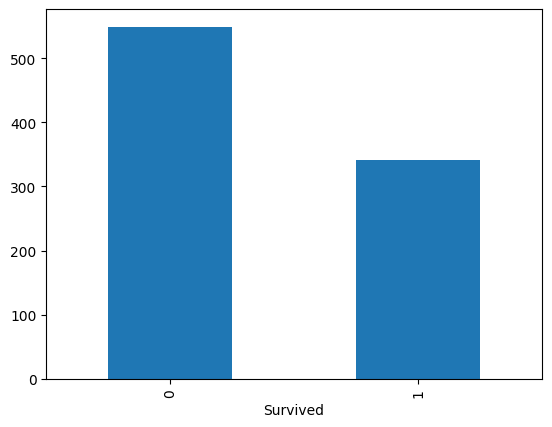

In [ ]:
# 탐색적 데이터 분석

print(df_train['Survived'].value_counts())
df_train['Survived'].value_counts().plot.bar()

# survived 앞글자 소문자로 작성했더니 오류 발생
# 0: 생존X, 1: 생존

Pclass
3    491
1    216
2    184
Name: count, dtype: int64
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


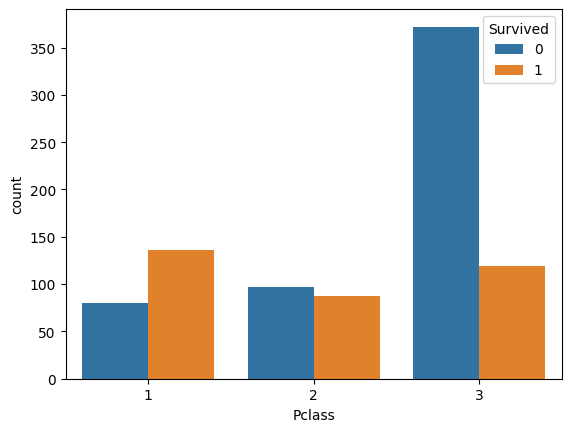

In [ ]:
# Survived 피처를 기준으로 그룹을 나누어, 그룹별 Pclass의  분포 살펴보기

# df_train: 데이터프레임에서 'Pclass' 컬럼만 뽑아 Series 객체
# value_counts(): 선택한 Series(여기서는 'Pclass')의 각 값이 몇 번 나오는지 세어서 반환

print(df_train['Pclass'].value_counts())

print(df_train['Pclass'].value_counts())
ax = sns.countplot(x='Pclass', hue='Survived', data=df_train)

# seaborn 라이브러리의 countplot을 이용해 'Pclass'별로 승객 수를 막대 그래프로 시각화
# x='Pclass': x축에 Pclass(1,2,3)를 표시
# hue='Survived': 막대를 생존 여부(Survived) 기준으로 색깔을 나눠서 시각화
#   → 같은 Pclass 안에서도 생존자/사망자를 색깔로 구분해 보여줌
# data=df_train: df_train 데이터를 기반으로 그래프를 그림

In [ ]:
from scipy import stats

# 두 집단의 피처를 비교해주며 탐색작업을 자동화하는 함수 정의

def valid_features(df, col_name, distribution_check=True):

  # 두 집단 (survived=1, survived=0)의 분포 그래프 출력
  g = sns.FacetGrid(df, col='Survived')
  g.map(plt.hist, col_name, bins=30)

  # 두 집단 (survived=1, survived=0)의 표준편차 각각 출력
  titanic_survived = df[df['Survived'] == 1]
  titanic_survived_Static = np.array(titanic_survived[col_name])
  print('data std is', '%.2f' % np.std(titanic_survived_Static))

  titanic_n_survived = df[df['Survived'] == 0]
  titanic_n_survived_Static = np.array(titanic_n_survived[col_name])
  print('data std is', '%.2f' % np.std(titanic_n_survived_Static))

  # (titanic_n_survived_static으로 작성시 오류 발생)

  # T-test로 두 집단의 평균 차이 검정
  tTestResult = stats.ttest_ind(titanic_survived[col_name], titanic_n_survived[col_name])
  tTestResultDiffVar = stats.ttest_ind(titanic_survived[col_name], titanic_n_survived[col_name], equal_var=False)
  print("The t-statistic and p-value assuming equal variances is %.3f and %.3f." % tTestResult)
  print("The t-statistic and p-value not assuming equal variances is %.3f and %.3f" % tTestResultDiffVar)

  if distribution_check:
    # Shapiro-Wilk 검정 : 분포의 정규성 정도를 검증합니다.
    print("The w-statistic and p-value in Survived %.3f and %.3f" % stats.shapiro(titanic_survived[col_name]))
    print("The w-statistic and p-value in Non-Survived %.3f and %.3f" % stats.shapiro(titanic_n_survived[col_name]))